Ejecutando simulaciones con matriz de transición...

=== GRÁFICOS TRADICIONALES ===


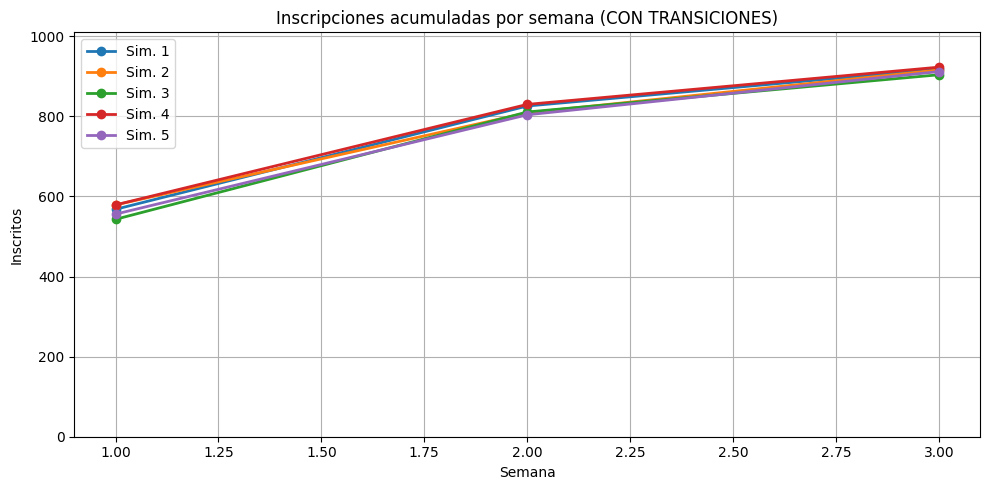

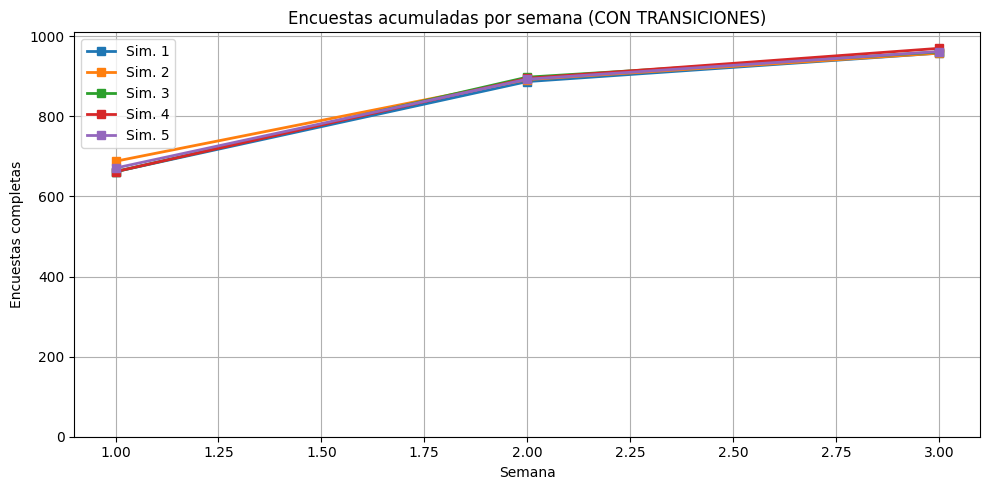


=== NUEVOS ANÁLISIS CON MARKOV ===


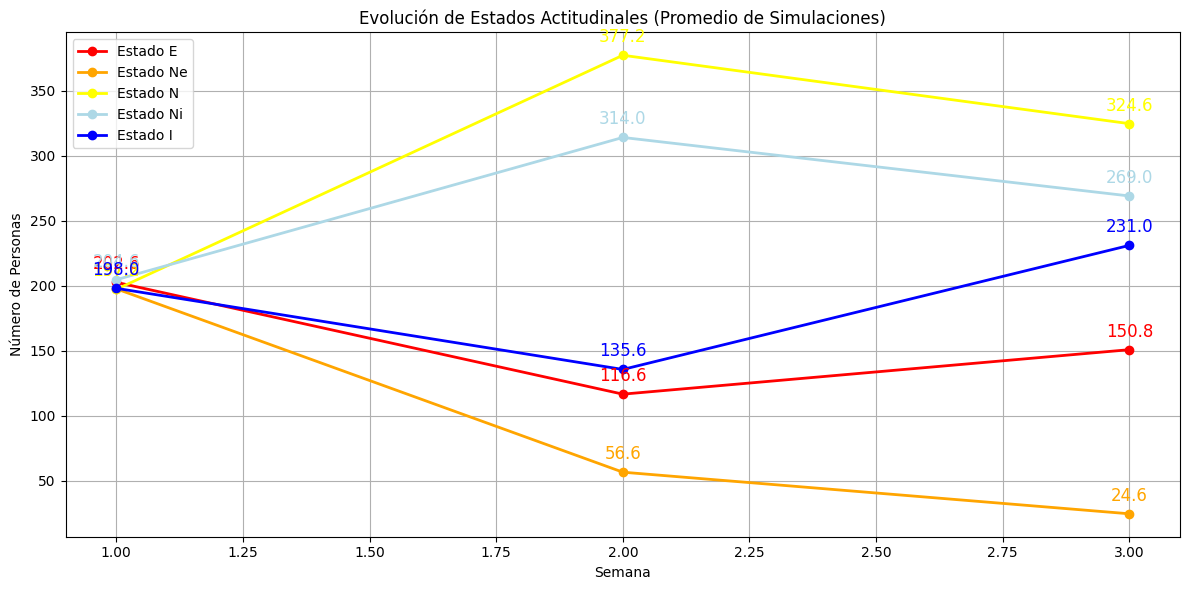


=== COMPARACIÓN CON/SIN TRANSICIONES ===


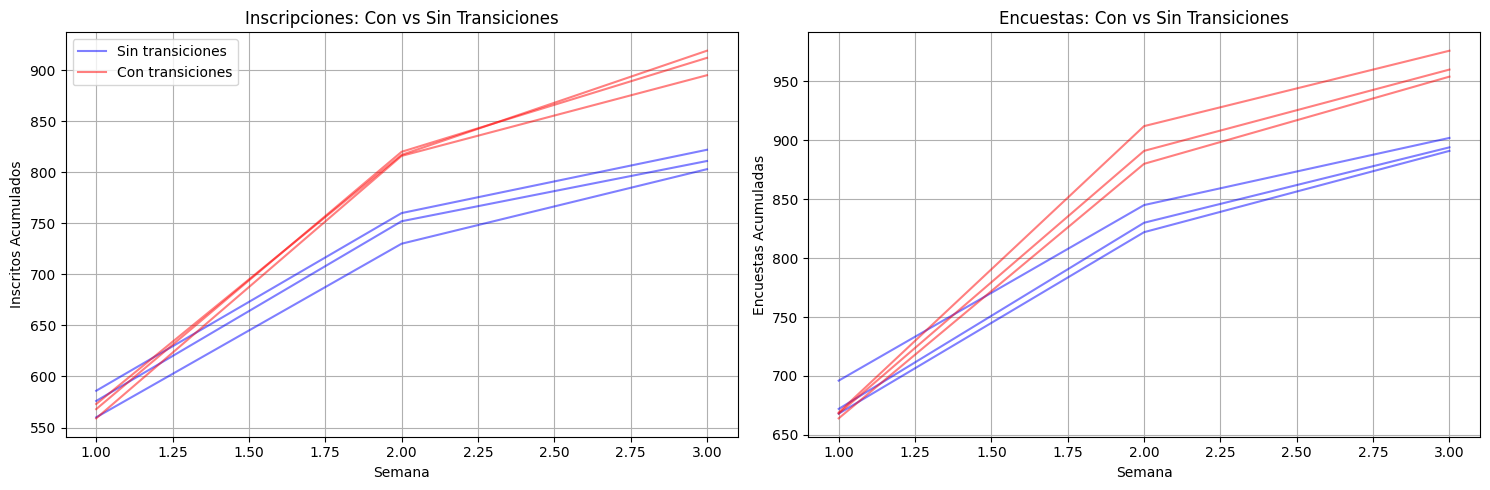


== RESULTADOS FINALES SIN TRANSICIÓN DE MARKOV ==
Inscripciones - Media: 812.00, Desv. Est.: 7.79
Encuestas     - Media: 895.67, Desv. Est.: 4.64

== RESULTADOS FINALES CON MARKOV ==
Inscripciones - Media: 908.67, Desv. Est.: 10.08
Encuestas     - Media: 963.33, Desv. Est.: 9.29


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Leer tu dataset (emociones.csv limpio con ; como separador)
df = pd.read_csv("../../../docs/poblaciones/HMM csv/emocionesGenerales.csv", sep=";")

# Mapa de emociones a números
estado_map = {"E": 0, "Ne": 1, "N": 2, "Ni": 3, "I": 4}
estado_inv_map = {v: k for k, v in estado_map.items()}

# Codificar
df_cod = df.map(estado_map.get)

# Crear matriz 5x5
trans_matrix = np.zeros((5, 5), dtype=int)

# Llenar la matriz con datos reales
for _, row in df_cod.iterrows():
    secuencia = row.tolist()
    for i in range(len(secuencia) - 1):
        origen = secuencia[i]
        destino = secuencia[i + 1]
        trans_matrix[origen, destino] += 1

# Normalizar a probabilidades
trans_probs = trans_matrix / trans_matrix.sum(axis=1, keepdims=True)


# ---------- PARÁMETROS GENERALES ----------
N_PERSONAS = 1000  # Número total de personas simuladas
ESTADOS = ['E', 'Ne', 'N', 'Ni', 'I']  # Estados actitudinales posibles

# Probabilidades de inscripción y de respuesta a la encuesta según el estado
PROB_X_ESTADO = {
    'E':  (0.90, 0.95),  # Muy entusiasta
    'Ne': (0.70, 0.80),  # Neutral-entusiasta
    'N':  (0.70, 0.80),  # Neutral
    'Ni': (0.45, 0.60),  # Neutral-indiferente
    'I':  (0.10, 0.25)   # Indiferente
}


# Mapeo de estados a índices
ESTADO_MAP = {"E": 0, "Ne": 1, "N": 2, "Ni": 3, "I": 4}
ESTADO_INV_MAP = {v: k for k, v in ESTADO_MAP.items()}

# ---------- FUNCIONES PRINCIPALES ----------

def transicionar_estados(estados_actuales, trans_probs):
    """
    Aplicar: Matriz de transición, cambia el estado de las personas. 2 simulaciones → Con y sin cambios de estado
    """
    nuevos_estados = np.copy(estados_actuales)
    
    for i, estado_actual in enumerate(estados_actuales):
        estado_idx = ESTADO_MAP[estado_actual]
        # Usar la fila correspondiente de la matriz como probabilidades
        probs = trans_probs[estado_idx]
        # Elegir nuevo estado basado en las probabilidades
        nuevo_estado_idx = np.random.choice(len(ESTADOS), p=probs)
        nuevos_estados[i] = ESTADO_INV_MAP[nuevo_estado_idx]
    
    return nuevos_estados

def simulacion_con_transiciones(n_semanas: int, trans_probs):
    """
    Simulación: Comportamiento con transiciones de estado cada semana.
    """
    # Estados iniciales aleatorios
    estados = np.random.choice(ESTADOS, size=N_PERSONAS)
    inscrito = np.zeros(N_PERSONAS, dtype=bool)
    encuestado = np.zeros(N_PERSONAS, dtype=bool)

    acumulado_insc = []
    acumulado_enc = []
    historial_estados = []  # Para rastrear la evolución de estados

    for semana in range(n_semanas):
        # Aplicar transiciones de estado (excepto la primera semana)
        if semana > 0:
            estados = transicionar_estados(estados, trans_probs)
        
        # Guardar distribución de estados de esta semana
        conteo_estados = {estado: np.sum(estados == estado) for estado in ESTADOS}
        historial_estados.append(conteo_estados.copy())
        
        # Simular inscripciones basadas en estados actuales
        pendientes_insc = ~inscrito
        if pendientes_insc.any():
            probs_insc = np.array([PROB_X_ESTADO[e][0] for e in estados])
            rand_vals = np.random.random(N_PERSONAS)
            nuevos = pendientes_insc & (rand_vals < probs_insc)
            inscrito[nuevos] = True

        # Simular encuestas basadas en estados actuales
        pendientes_enc = ~encuestado
        if pendientes_enc.any():
            probs_enc = np.array([PROB_X_ESTADO[e][1] for e in estados])
            rand_vals = np.random.random(N_PERSONAS)
            nuevos = pendientes_enc & (rand_vals < probs_enc)
            encuestado[nuevos] = True

        # Guardar acumulados
        acumulado_insc.append(int(inscrito.sum()))
        acumulado_enc.append(int(encuestado.sum()))

        # Si ya todos están inscritos y encuestados
        if inscrito.all() and encuestado.all():
            faltan = n_semanas - len(acumulado_insc)
            acumulado_insc.extend([N_PERSONAS]*faltan)
            acumulado_enc.extend([N_PERSONAS]*faltan)
            # Completar historial de estados
            for _ in range(faltan):
                historial_estados.append(conteo_estados.copy())
            break

    return acumulado_insc, acumulado_enc, historial_estados

def ejecutar_simulaciones_markov(n_semanas: int, n_sim: int):
    """
    Ejecuta múltiples simulaciones con matriz de transición.
    """
    resultados = []
    
    for _ in range(n_sim):
        insc, enc, estados_hist = simulacion_con_transiciones(n_semanas, trans_probs)
        resultados.append({
            'inscritos': insc, 
            'encuestas': enc,
            'estados_historia': estados_hist
        })
    
    return resultados

# ---------- NUEVAS VISUALIZACIONES ----------
# Gráfica: ¿Cómo evolucionan los estados a lo largo del tiempo?

def graficar_evolucion_estados(resultados, n_semanas):
    semanas = np.arange(1, n_semanas + 1)

    # Promediar across simulaciones
    estados_promedio = {estado: [] for estado in ESTADOS}

    for semana_idx in range(n_semanas):
        for estado in ESTADOS:
            valores_semana = [r['estados_historia'][semana_idx][estado] 
                              for r in resultados]
            estados_promedio[estado].append(np.mean(valores_semana))

    plt.figure(figsize=(12, 6))
    colors = ['red', 'orange', 'yellow', 'lightblue', 'blue']

    for i, estado in enumerate(ESTADOS):
        valores = estados_promedio[estado]
        plt.plot(semanas, valores, 
                 marker='o', linewidth=2, label=f"Estado {estado}",
                 color=colors[i])
        # Agregar etiquetas numéricas en cada punto
        for x, y in zip(semanas, valores):
            plt.text(x, y + 10, f"{y:.1f}", ha='center', fontsize=12, color=colors[i])

    plt.title("Evolución de Estados Actitudinales (Promedio de Simulaciones)")
    plt.xlabel("Semana")
    plt.ylabel("Número de Personas")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def comparar_con_sin_transiciones(n_semanas, n_sim):
    # Simulaciones originales (sin transiciones)
    resultados_orig = []
    for _ in range(n_sim):
        estados = np.random.choice(ESTADOS, size=N_PERSONAS)
        inscrito = np.zeros(N_PERSONAS, dtype=bool)
        encuestado = np.zeros(N_PERSONAS, dtype=bool)
        
        acum_insc, acum_enc = [], []
        for semana in range(n_semanas):
            # Sin cambios de estado
            pendientes_insc = ~inscrito
            if pendientes_insc.any():
                probs_insc = np.array([PROB_X_ESTADO[e][0] for e in estados])
                rand_vals = np.random.random(N_PERSONAS)
                nuevos = pendientes_insc & (rand_vals < probs_insc)
                inscrito[nuevos] = True
            
            pendientes_enc = ~encuestado
            if pendientes_enc.any():
                probs_enc = np.array([PROB_X_ESTADO[e][1] for e in estados])
                rand_vals = np.random.random(N_PERSONAS)
                nuevos = pendientes_enc & (rand_vals < probs_enc)
                encuestado[nuevos] = True
            
            acum_insc.append(inscrito.sum())
            acum_enc.append(encuestado.sum())
        
        resultados_orig.append({'inscritos': acum_insc, 'encuestas': acum_enc})
    
    # Simulaciones con transiciones
    resultados_markov = ejecutar_simulaciones_markov(n_semanas, n_sim)
    
    # Comparar
    plt.figure(figsize=(15, 5))
    semanas = np.arange(1, n_semanas+1)
    
    # Inscripciones
    plt.subplot(1, 2, 1)
    for r in resultados_orig:
        plt.plot(semanas, r['inscritos'], alpha=0.5, color='blue', label='Sin transiciones' if r == resultados_orig[0] else "")
    for r in resultados_markov:
        plt.plot(semanas, r['inscritos'], alpha=0.5, color='red', label='Con transiciones' if r == resultados_markov[0] else "")
    
    plt.title("Inscripciones: Con vs Sin Transiciones")
    plt.xlabel("Semana")
    plt.ylabel("Inscritos Acumulados")
    plt.legend()
    plt.grid(True)
    
    # Encuestas
    plt.subplot(1, 2, 2)
    for r in resultados_orig:
        plt.plot(semanas, r['encuestas'], alpha=0.5, color='blue')
    for r in resultados_markov:
        plt.plot(semanas, r['encuestas'], alpha=0.5, color='red')
    
    plt.title("Encuestas: Con vs Sin Transiciones")
    plt.xlabel("Semana")
    plt.ylabel("Encuestas Acumuladas")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return  resultados_markov, resultados_orig
    
# ---------- EJECUCIÓN ----------

if __name__ == "__main__":
    # Inputs
    n_semanas = int(input("Número de semanas (ej. 10): "))
    n_simulaciones = int(input("Número de simulaciones (ej. 5): "))
    
    print("Ejecutando simulaciones con matriz de transición...")
    resultados = ejecutar_simulaciones_markov(n_semanas, n_simulaciones)
    
    # Visualizaciones originales
    print("\n=== GRÁFICOS TRADICIONALES ===")
    
    # Función auxiliar para usar las funciones originales
    def graficar_ojivas(resultados, n_semanas):
        semanas = np.arange(1, n_semanas+1)
        
        plt.figure(figsize=(10,5))
        for i, r in enumerate(resultados, 1):
            plt.plot(semanas, r['inscritos'], marker='o', linewidth=2, label=f"Sim. {i}")
        plt.title("Inscripciones acumuladas por semana (CON TRANSICIONES)")
        plt.xlabel("Semana"); plt.ylabel("Inscritos")
        plt.ylim(0, N_PERSONAS+10); plt.grid(True); plt.legend(); plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(10,5))
        for i, r in enumerate(resultados, 1):
            plt.plot(semanas, r['encuestas'], marker='s', linewidth=2, label=f"Sim. {i}")
        plt.title("Encuestas acumuladas por semana (CON TRANSICIONES)")
        plt.xlabel("Semana"); plt.ylabel("Encuestas completas")
        plt.ylim(0, N_PERSONAS+10); plt.grid(True); plt.legend(); plt.tight_layout()
        plt.show()
    
    graficar_ojivas(resultados, n_semanas)
    
    # Nuevas visualizaciones
    print("\n=== NUEVOS ANÁLISIS CON MARKOV ===")
    graficar_evolucion_estados(resultados, n_semanas)
    
    print("\n=== COMPARACIÓN CON/SIN TRANSICIONES ===")
    resultados_markov, resultados_orig = comparar_con_sin_transiciones(n_semanas, min(n_simulaciones, 3))  # Limitamos para claridad visual
    
    inscritos_finales_sin = [r['inscritos'][-1] for r in resultados_orig]
    encuestas_finales_sin = [r['encuestas'][-1] for r in resultados_orig]

    inscritos_finales_con = [r['inscritos'][-1] for r in resultados_markov]
    encuestas_finales_con = [r['encuestas'][-1] for r in resultados_markov]

    # Mostrar resultados finales
    print("\n== RESULTADOS FINALES SIN TRANSICIÓN DE MARKOV ==")
    print(f"Inscripciones - Media: {np.mean(inscritos_finales_sin):.2f}, Desv. Est.: {np.std(inscritos_finales_sin):.2f}")
    print(f"Encuestas     - Media: {np.mean(encuestas_finales_sin):.2f}, Desv. Est.: {np.std(encuestas_finales_sin):.2f}")

    print("\n== RESULTADOS FINALES CON MARKOV ==")
    print(f"Inscripciones - Media: {np.mean(inscritos_finales_con):.2f}, Desv. Est.: {np.std(inscritos_finales_con):.2f}")
    print(f"Encuestas     - Media: {np.mean(encuestas_finales_con):.2f}, Desv. Est.: {np.std(encuestas_finales_con):.2f}")


